# Midterm Project
- AIGC 5500 0NA
- Advanced Deep Learning
- Summer 2026


### Team Info
HawkAI Detection | Group 1
| Name | Github |
| --- | --- |
| Kevin Joseff Cabrera (Kevin) | https://github.com/kjcabPL |
| Mohd Mujtaba Saighani (Mujtaba) | https://github.com/saigha1 |
| Thiago Segantini Nogeuira (Thiago) | https://github.com/thiaseg |
| Sayamon Sittiprom (Saya) | https://github.com/sittiprom |
| Yao-Fu Yang (Andy) | https://github.com/yaofu-yang |

### 1. Overview (Project Instructions)
In the activation functions and gradient descent module, you studied variations of gradient descent
and the hyperparameters that govern training dynamics. This project puts that knowledge to work:
you will systematically compare three modern optimizers on a real image-classification task, analyze
how each one behaves under different hyperparameter settings, and communicate your findings in a
live group presentation.
- Objective: Implement, tune, and compare Adam, RMSprop, and AdamW on a feedforward
neural network trained on the KMNIST dataset, and draw evidence-based conclusions about
their relative strengths and trade-offs.
- Importance: Choosing the wrong optimizer or leaving hyperparameters at default values is
one of the most common causes of poor model performance. This project builds the analytical
habits you will carry into every future deep learning task.

### 2. Dataset (Project Instructions)
Use the KMNIST (Kuzushiji-MNIST) dataset, available directly through PyTorch:
| Property | Details |
|---|---|
|Training Samples| 60,000 Images|
|Test Samples| 10,000 Images|
|Image Size | 28 x 28 Pixels, Greyscale|
|Classes| 10 (Japanese Hiragana Characters)|
|Complexity| Higher than MNIST; class boundaries overlap|


In [2]:
# Handle all imports first
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

# Kuzushiji-MNIST Dataset
from torchvision.datasets import KMNIST
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import KFold
from typing import Type, Dict, Any, Callable
import numpy as np
from matplotlib import pyplot as plt
import time

In [3]:
# Define data preparation constants
MANUAL_SEED = 498
ROOT ='./kuzushiji_data'
OPTUNA_TRIALS = 8

In [4]:
# Load the data and complete basic exploration

# Setting the random seed
torch.manual_seed(MANUAL_SEED)

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load Training data as a single batch to compute mean and standard deviation
# Define a transformation to Tensor
transform = transforms.Compose([transforms.ToTensor()])
trainset = KMNIST(root=ROOT, train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=len(trainset), shuffle=True)
data = next(iter(trainloader))
mean = data[0].mean().item()
stddev = data[0].std().item()
print(f"The mean is : {mean}")
print(f"The standard deviation is: {stddev}")


Using device: cpu
The mean is : 0.19176216423511505
The standard deviation is: 0.3483428359031677


In [5]:
# Check data shape
# (Batch Size, Channel Counts, Row Pixels, Column Pixels)
data[0].size()

torch.Size([60000, 1, 28, 28])

In [6]:
# Prepare the data

# Apply Input Standardization to reduce risk of saturating neurons
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize([mean], [stddev])])

# Create training and testing sets while applying standardization
trainset = KMNIST(root=ROOT, train=True, download=True, transform=transform)
testset = KMNIST(root=ROOT, train=False, download=True, transform=transform)


# Verify final dimension of all three data sets
print(f"Train set size: {len(trainset)}")
print(f"Test set size: {len(testset)}")

Train set size: 60000
Test set size: 10000


# 3. Model Architecture (Project Instructions)
Implement the following feedforward fully-connected architecture. Do not modify it; the architecture is fixed so that all differences between runs are attributable to the optimizer and its hyperparameters.

|Layer|Configuration|Notes
|---|---|---|
|Input|784 Neurons|Flatten 28x28 image|
|Hidden 1|128 Neurons, ReLU Activation||
|Hidden 1|64 Neurons, ReLU Activation||
|Output|10 Neurons, Softmax activation|One neuron per class|
|Loss function|Cross-Entropy Loss|Appropriate for multi-class classification|


In [7]:
# Define architectural constants
INPUT_DIM = 784  # Cannot change
HIDDEN_DIM1 = 128  # Cannot change
HIDDEN_DIM2 = 64  # Cannot change
OUTPUT_DIM = 10  # Cannot change

In [8]:
# Define the forward pass. Final activation is omitted since softmax is part of
# cross-entropy loss function in PyTorch.
class FeedForwardNet(nn.Module):
    def __init__(
        self,
        input_dim:  int = INPUT_DIM,
        hidden_dim1: int = HIDDEN_DIM1,
        hidden_dim2: int = HIDDEN_DIM2,
        output_dim: int = OUTPUT_DIM
    ) -> None:
        super().__init__()
        # First Hidden Layer
        self.hidden1 = nn.Linear(input_dim, hidden_dim1)
        # Apply BatchNorm to first hidden layer
        self.batchNorm1 = nn.BatchNorm1d(num_features=hidden_dim1)
        # Apply random deactivation of neurons to reduce overfitting
        self.dropout1 = nn.Dropout(p=0.2)

        # Second Hidden Layer
        self.hidden2 = nn.Linear(hidden_dim1, hidden_dim2)
        # Apply BatchNorm to second hidden layer
        self.batchNorm2 = nn.BatchNorm1d(num_features=hidden_dim2)
        # Apply random deactivation of neurons to reduce overfitting
        self.dropout2 = nn.Dropout(p=0.2)

        # Final Output Layer
        self.output = nn.Linear(hidden_dim2, output_dim)

        # Customized function to initialize weights for each layer.
        self._initialize_weights()

    # Applies Weight Initialization technique.
    def _initialize_weights(self) -> None:
        # Kaiming (He) initialization for first hidden layer
        nn.init.kaiming_normal_(self.hidden1.weight, nonlinearity='relu')
        nn.init.constant_(self.hidden1.bias, 0.0)

        # Same for second hidden layer
        nn.init.kaiming_normal_(self.hidden2.weight, nonlinearity='relu')
        nn.init.constant_(self.hidden2.bias, 0.0)

        # Xavier (Glorot) initialization for the output layer (no activation).
        nn.init.xavier_uniform_(self.output.weight)
        nn.init.constant_(self.output.bias, 0.0)

    # Completes the forward pass
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Flatten the image from 28x28 to 784 pixels
        x = torch.flatten(x, start_dim=1)

        # First layers (hidden, batchnorm, relu activation, dropout)
        x = self.hidden1(x)
        x = self.batchNorm1(x)
        x = F.relu(x)
        x = self.dropout1(x)

        # Second Layers (hidden, batchnorm, relu activation, dropout)
        x = self.hidden2(x)
        x = self.batchNorm2(x)
        x = F.relu(x)
        x = self.dropout2(x)

        return self.output(x)    # Raw logits; softmax applied by loss function.

# Initializes the model.
model = FeedForwardNet()

# 4. Optimizers Under Investigation (Project Instructions)
You will train and evaluate the same fixed architecture using each of the three optimizers below. For 
every optimizer, perform a structured hyperparameter search (see Section 5) and report results for 
both the default configuration and the best configuration found. 
 
### 4.1  Adam (Adaptive Moment Estimation) 
- Key idea: Maintains separate adaptive learning rates for each parameter by combining first-
moment (momentum) and second-moment (uncentred variance) estimates. 
- Default settings: lr = 0.001, β1 = 0.9, β2 = 0.999, ε = 1e-8. 
- Investigate: The effect of learning rate and β1 on convergence speed and final accuracy. 
 
### 4.2  RMSprop (Root Mean Square Propagation) 
- Key idea: Divides the learning rate by a running average of the squared gradient magnitudes, 
preventing updates from growing too large. 
- Default settings: lr = 0.01, α = 0.99, ε = 1e-8. 
- Investigate: The effect of the decay factor α and learning rate on training stability. 
 
### 4.3  AdamW (Adam with Decoupled Weight Decay) 
- Key  idea:  Corrects a known flaw in Adam’s L2 regularization by decoupling weight decay 
from the adaptive learning-rate update, leading to better generalization. 
- Default settings: lr = 0.001, β1 = 0.9, β2 = 0.999, ε = 1e-8, weight_decay = 0.01. 
- Investigate: The effect of weight_decay and learning rate on the gap between training and 
test accuracy. 

### Branch TODO 1: Research the Assigned Optimizer
The project instructions give a brief overview of the key ideas, default settings, and investigation pathways for each optimizer. Start by completing the investigation tasks but go deeper to find other intereting and unique parameters/features of each optimizer (including ones not covered in lecture).

Action Item: Add a document in the branch with the findings, or include the findings directly in the notebook. For reference, the final PDF report requires the following: "Optimizer descriptions and theoretical background"

In [9]:
# Define adjustable constants
EPOCHS = 20 # Min 20
BATCH_SIZE = 64  # May change
K_FOLD = 5 # Cannot change
TARGET_ACC = 0.6 # Will change

# Methodology (Project Instructions)
### 5.1  Hyperparameter Search 
For each optimizer, evaluate at least four (4) distinct hyperparameter configurations. You may use 
grid search, random search, or a manual systematic approach. Document your search strategy and 
justify your final selection. 
 
At minimum, vary the following for each optimizer: 
- Learning  rate: try values  spanning  at  least  two  orders  of magnitude (e.g.,  0.1,  0.01,  0.001, 
0.0001). 
- At least one optimizer-specific hyperparameter (e.g., β1 for Adam/AdamW, decay factor for 
RMSprop).

### 5.2  Cross-Validation 
- Apply 5-fold cross-validation on the training set to estimate generalization performance. 
- Report  the  mean  and  standard  deviation  of  validation  accuracy  across  folds  for  each 
configuration. 
- Use the best configuration identified through cross-validation to train a final model on the full 
training set.

### 5.3  Training Protocol 
- Train  for  a  fixed  number  of  epochs  (minimum  20)  across  all  configurations  to  ensure  fair 
comparison. 
- Use the same random seed for all runs to control for initialization variance. 
- Record training loss, validation loss, and validation accuracy at each epoch. 
- Evaluate the final model on the held-out test set; report test accuracy and test loss.

### 5.4  Metrics to Record
|Metric|Description|
|---|---|
|Training Accuracy|Accuracy on the training set at the final epoch|
|Validation Accuracy|Mean cross-validation accuracy (and std dev) across 5 folds|
|Test Accuracy|Accuracy on the held-out test set |
|Final Loss|Training and test loss at the end of training|
|Convergence Speed|Number of epochs to reach a target validation accuracy (e.g., 
80%)|
|Training Time|Wall-clock time for a full training run|

In [10]:
# Define a reusable run Epoch function for both training & evaluation loops
def run_epoch(
    model:     nn.Module,
    loader:    DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer | None,
    device:    torch.device,
    training:  bool,
) -> tuple[float, float]:
    """Run one full pass over the DataLoader.
    Pass optimizer=None during evaluation.
    Returns (mean loss, accuracy).
    """
    model.train() if training else model.eval()

    total_loss    = 0.0
    total_correct = 0
    total_samples = 0

    # No gradient/back propagation if in evaluation mode.
    context = torch.enable_grad() if training else torch.no_grad()

    with context:
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            # Cross-entropy loss does not need one-hot targets in PyTorch.
            loss = criterion(outputs, targets)

            # Only run for training mode. Evaluation mode skips this.
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            # Accumulate metrics.
            _, predicted   = torch.max(outputs, dim=1)
            total_correct += (predicted == targets).sum().item()
            total_samples += targets.size(0)
            total_loss    += loss.item()

    return total_loss / len(loader), total_correct / total_samples

In [11]:
# Define a reusable k-fold cross-validation function for different optimizers
# Handles the requirements in 5.2 Cross Validation & 5.3 Training Protocol

def cross_validate_config(
    model_class: Callable[[], nn.Module],  # Need a fresh model for each fold
    train_dataset: Any,
    optimizer_class: Type[torch.optim.Optimizer],  # Type of optimizer
    optimizer_kwargs: Dict[str, Any],  # Hyperparameters
    criterion: nn.Module,
    device: torch.device,
    epochs: int = EPOCHS,  # 5.3 Req, min 20 Epochs
    batch_size: int = BATCH_SIZE,
    n_splits: int = K_FOLD,  # 5.2 Req: 5-fold
    random_seed: int = MANUAL_SEED,

) -> tuple[float, float]:
    """
    Performs K-Fold Cross-Validation for a given model, optimizer,
    and hyperparameter configuration.

    Returns:
        tuple: (
            mean_accuracy,       # mean validation accuracy across folds
            std_accuracy,        # std dev of validation accuracy across folds
            fold0_train_losses,  # per-epoch train losses (fold 1 only, for plotting)
            fold0_val_losses,    # per-epoch val losses (fold 1 only, for plotting)
        )
    """
    k_fold = KFold(n_splits=n_splits, shuffle=True, random_state=random_seed)
    fold0_train_losses, fold0_val_losses = [], []
    fold_best_accuracies = []
    fold_train_times = []
    
    for fold, (train_idx, val_idx) in enumerate(k_fold.split(train_dataset)):
        # 5.3 Req: Use the same random seed for all runs to control for initialization variance.
        torch.manual_seed(random_seed)

        # Add time recording for each training fold
        fold_start_time = time.perf_counter()
        
        # Move model to device
        model = model_class().to(device)
        
        # Create optimizer using the class and parameter arguments
        optimizer = optimizer_class(model.parameters(), **optimizer_kwargs)
        
        # Generate the training folds and validation fold
        train_sub = Subset(train_dataset, train_idx)
        val_sub   = Subset(train_dataset, val_idx)
        
        # Generate the training and validation loaders
        trainloader = DataLoader(train_sub, batch_size=batch_size, shuffle=True)
        valloader   = DataLoader(val_sub, batch_size=batch_size, shuffle=False)
        
        # For tracking accuracy
        best_fold_val_acc = 0.0
        
        # Complete the training and validation per Epoch and capture metrics
        for epoch in range(epochs):
            # Training loop with the training loss and training accuracy
            train_loss, train_acc = run_epoch(
                model, trainloader, criterion, optimizer, device, training=True
            )

            # Validation loop with the validation loss and validation accuracy
            # No optimizers needed for validation, training pathway should not be run
            val_loss, val_acc = run_epoch(
                model, valloader, criterion, optimizer=None, device=device, training=False
            )
            
            # Update the best validation accuracy
            if val_acc > best_fold_val_acc:
                best_fold_val_acc = val_acc

            if fold == 0:
                fold0_train_losses.append(train_loss)
                fold0_val_losses.append(val_loss)    

            # Report Epoch & Losses/Accuracies
            print(f"Fold {fold + 1}/{n_splits} Epoch {epoch + 1}/{epochs} | Training Accuracy: {(train_acc * 100):.2f}% | Validation Accuracy: {(val_acc * 100):.2f}%")

        # Record training time for current fold
        fold_end_time = time.perf_counter()
        fold_train_time = (fold_end_time - fold_start_time) / 60 # Converted to minutes
        
        # Tracking validation accuracies
        fold_best_accuracies.append(best_fold_val_acc)
        fold_train_times.append({
            "fold": fold + 1, 
            "epochs": epochs,
            "time": fold_train_time
        })
        print(f"    Fold {fold + 1} Best Val Acc: {best_fold_val_acc:.4f} ({(best_fold_val_acc * 100):.2f})%")
        print(f"    Fold {fold + 1} Total Training Time: {fold_train_time:.2f} mins.")
    # Calculate aggregated statistics
    acc_tensor = torch.tensor(fold_best_accuracies)

    # 5.2 Req: report mean and standard deviation of validation accuracies
    # Needed for 6.2 plotting accuracy distribution as well.
    return acc_tensor.mean().item(), acc_tensor.std().item(), fold0_train_losses, fold0_val_losses



# Branch TODO 2
Modify the code below for your selected optimizer (Adam, RMSProp, AdamW).
Make sure to include the hyperparameter changes that were identified in TODO 1/Section 4.
Consider also changing the architecture to use Optuna or Ray Tune as discussed in lecture.
The reusable cross-validation function should be compatible with both approaches, but feel free to modify the function with design improvements, etc.

- Learning  rate: try values  spanning  at  least  two  orders  of magnitude (e.g.,  0.1,  0.01,  0.001, 
0.0001). 

Testing config 1/9: {'lr': 0.01, 'alpha': 0.99, 'eps': 1e-08}
Fold 1/5 Epoch 1/20 | Training Accuracy: 84.56% | Validation Accuracy: 91.88%
Fold 1/5 Epoch 2/20 | Training Accuracy: 90.01% | Validation Accuracy: 93.33%
Fold 1/5 Epoch 3/20 | Training Accuracy: 91.41% | Validation Accuracy: 93.97%
Fold 1/5 Epoch 4/20 | Training Accuracy: 92.16% | Validation Accuracy: 94.43%
Fold 1/5 Epoch 5/20 | Training Accuracy: 92.65% | Validation Accuracy: 94.77%
Fold 1/5 Epoch 6/20 | Training Accuracy: 93.08% | Validation Accuracy: 94.87%
Fold 1/5 Epoch 7/20 | Training Accuracy: 93.61% | Validation Accuracy: 94.92%
Fold 1/5 Epoch 8/20 | Training Accuracy: 93.75% | Validation Accuracy: 95.00%
Fold 1/5 Epoch 9/20 | Training Accuracy: 94.11% | Validation Accuracy: 94.99%
Fold 1/5 Epoch 10/20 | Training Accuracy: 94.18% | Validation Accuracy: 94.97%
Fold 1/5 Epoch 11/20 | Training Accuracy: 94.14% | Validation Accuracy: 94.97%
Fold 1/5 Epoch 12/20 | Training Accuracy: 94.40% | Validation Accuracy: 95.19%

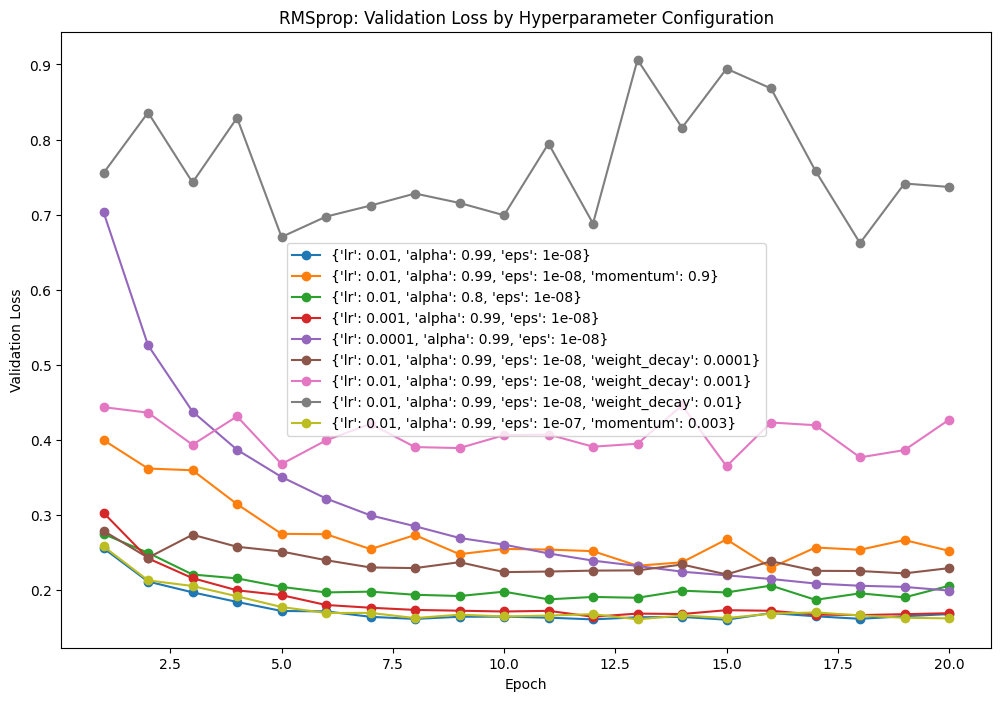

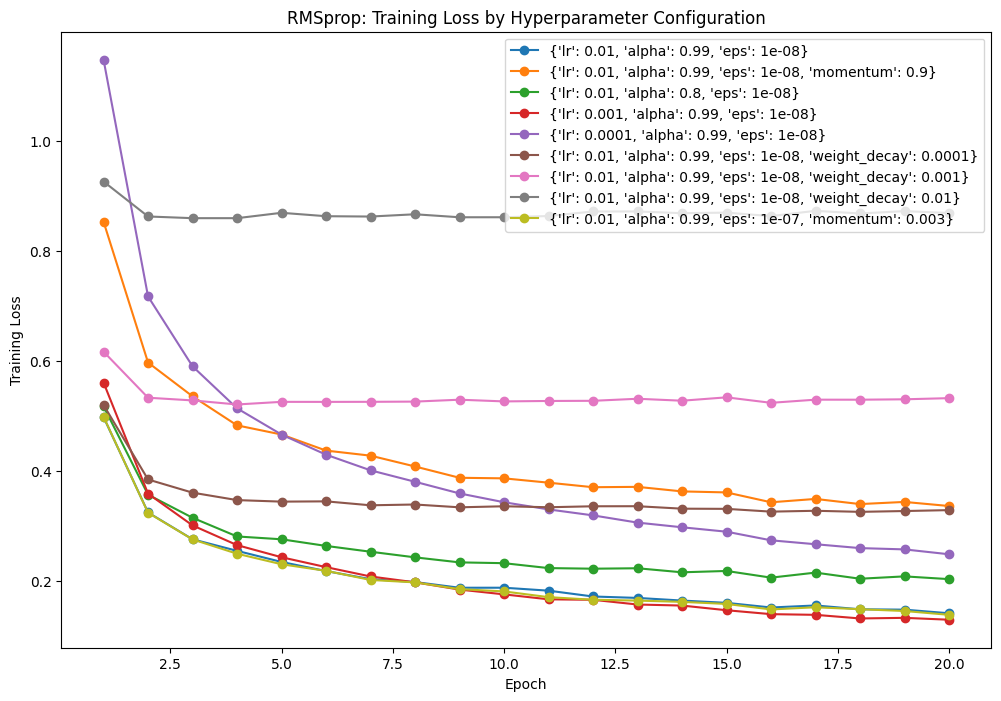

In [19]:
# Example code for optimizer trials with different hyperparameter configurations

optimizer_name = "RMSprop"
optimizer_class = torch.optim.RMSprop

# Define sample hyperparamters.
# To fulfill requirements, need to have four unique configurations
# hyperparameters = [
#     {"lr" :0.01, "alpha" : 0.99, "eps" :1e-8},
#     {"lr": 0.01,   "alpha": 0.99, "eps": 1e-8, "momentum":  0.9},
#     # {"lr": 0.01,   "alpha": 0.99, "eps": 1e-8, "momentum":  0.001},
#     {"lr": 0.01,   "alpha": 0.99, "eps": 1e-8, "momentum":  0.003},
#     {"lr": 0.01,   "alpha": 0.80, "eps": 1e-8, "momentum":  0.003},
#     {"lr": 0.01,   "alpha": 0.99,  "eps": 1e-07, "momentum":  0.003},
#      {"lr": 0.001,   "alpha": 0.99, "eps": 1e-8, "momentum":  0.003 ,},
#      {"lr": 0.0001,   "alpha": 0.99, "eps": 1e-8, "momentum":  0.003,"weight_decay": 1e-2}
# ]

hyperparameters = [
    {"lr": 0.01,   "alpha": 0.99, "eps": 1e-8},                          
    {"lr": 0.01,   "alpha": 0.99, "eps": 1e-8, "momentum": 0.9},         
    {"lr": 0.01,   "alpha": 0.80, "eps": 1e-8},                          
    {"lr": 0.001,  "alpha": 0.99, "eps": 1e-8},                          
    {"lr": 0.0001, "alpha": 0.99, "eps": 1e-8},                          
    {"lr": 0.01,   "alpha": 0.99, "eps": 1e-8, "weight_decay": 1e-4},    
    {"lr": 0.01,   "alpha": 0.99, "eps": 1e-8, "weight_decay": 1e-3},    
    {"lr": 0.01,   "alpha": 0.99, "eps": 1e-8, "weight_decay": 1e-2},    
    {"lr": 0.01,   "alpha": 0.99,  "eps": 1e-07, "momentum":  0.003},
]



# Will store the results from the best configuration for this optimizer
best_configuration_results = {}

# Define evaluation metrics
best_config_score = -1.0
best_config_data = None
best_config_params = None
loss_histories = {} 

for config_idx, config_kwargs in enumerate(hyperparameters):
    # Example: Testing config 1/1: {"lr": 0.1, "weight_decay": 1e-4}
    print(f"Testing config {config_idx + 1}/{len(hyperparameters)}: {config_kwargs}")

    # Invoke the Cross-Validation function defined earlier
    result = cross_validate_config(
        model_class=FeedForwardNet,
        train_dataset=trainset,
        optimizer_class=optimizer_class,
        optimizer_kwargs=config_kwargs,
        criterion=nn.CrossEntropyLoss(),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        device=device
    )

    loss_histories[str(config_kwargs)] = {
    "train": result[2],
    "val": result[3],
}

    # Check and update for best results based on accuracy mean
    if result[0] > best_config_score:
        best_config_score = result[0]
        best_config_data = result
        best_config_params = config_kwargs

# This will be used for plotting later.
best_configuration_results[optimizer_name] = {
    "params": best_config_params,
    "metrics": best_config_data,
}

print(f"Best configuration: {best_config_params}")
print(f"Mean Validation Accuracy: {best_config_score:.4f}")


# Plot 1: Validation loss per config
plt.figure(figsize=(12, 8))
for label, losses in loss_histories.items():
    plt.plot(range(1, len(losses["val"]) + 1), losses["val"], marker='o', label=label)
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('RMSprop: Validation Loss by Hyperparameter Configuration')
plt.legend()
plt.show()

# Plot 2: Training loss per config 
plt.figure(figsize=(12, 8))
for label, losses in loss_histories.items():
    plt.plot(range(1, len(losses["train"]) + 1), losses["train"], marker='o', label=label)  # <- changed "val" to "train"
plt.xlabel('Epoch')
plt.ylabel('Training Loss')   
plt.title('RMSprop: Training Loss by Hyperparameter Configuration')  
plt.legend()
plt.show()


Optuna

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import sys
!{sys.executable} -m pip install optuna

  Using cached optuna-4.9.0-py3-none-any.whl.metadata (15 kB)
  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
Using cached optuna-4.9.0-py3-none-any.whl (425 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 22.1 MB/s  0:00:00
Using cached colorlog-6.10.1-py3-none-any.whl (11 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [optuna]2m3/5 [alembic]


/opt/anaconda3/envs/py-tf-torch-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|          | 0/20 [00:00<?, ?it/s]

Fold 1/5 Epoch 1/20 | Training Accuracy: 83.94% | Validation Accuracy: 91.20%
Fold 1/5 Epoch 2/20 | Training Accuracy: 88.99% | Validation Accuracy: 92.58%
Fold 1/5 Epoch 3/20 | Training Accuracy: 89.90% | Validation Accuracy: 93.21%
Fold 1/5 Epoch 4/20 | Training Accuracy: 90.46% | Validation Accuracy: 93.19%
Fold 1/5 Epoch 5/20 | Training Accuracy: 90.48% | Validation Accuracy: 93.22%
Fold 1/5 Epoch 6/20 | Training Accuracy: 90.95% | Validation Accuracy: 93.40%
Fold 1/5 Epoch 7/20 | Training Accuracy: 90.92% | Validation Accuracy: 93.35%
Fold 1/5 Epoch 8/20 | Training Accuracy: 90.71% | Validation Accuracy: 93.50%
Fold 1/5 Epoch 9/20 | Training Accuracy: 91.08% | Validation Accuracy: 93.95%
Fold 1/5 Epoch 10/20 | Training Accuracy: 91.01% | Validation Accuracy: 93.65%
Fold 1/5 Epoch 11/20 | Training Accuracy: 91.15% | Validation Accuracy: 93.72%
Fold 1/5 Epoch 12/20 | Training Accuracy: 91.07% | Validation Accuracy: 93.81%
Fold 1/5 Epoch 13/20 | Training Accuracy: 91.37% | Validation

Best trial: 0. Best value: 0.945317:   5%|▌         | 1/20 [03:13<1:01:15, 193.43s/it]

Fold 5/5 Epoch 20/20 | Training Accuracy: 91.27% | Validation Accuracy: 94.38%
    Fold 5 Best Val Acc: 0.9437 (94.38)%
    Fold 5 Total Training Time: 0.65 mins.
Fold 1/5 Epoch 1/20 | Training Accuracy: 83.57% | Validation Accuracy: 91.27%
Fold 1/5 Epoch 2/20 | Training Accuracy: 89.30% | Validation Accuracy: 93.13%
Fold 1/5 Epoch 3/20 | Training Accuracy: 91.08% | Validation Accuracy: 93.46%
Fold 1/5 Epoch 4/20 | Training Accuracy: 91.99% | Validation Accuracy: 94.05%
Fold 1/5 Epoch 5/20 | Training Accuracy: 92.58% | Validation Accuracy: 94.02%
Fold 1/5 Epoch 6/20 | Training Accuracy: 93.02% | Validation Accuracy: 94.46%
Fold 1/5 Epoch 7/20 | Training Accuracy: 93.39% | Validation Accuracy: 94.92%
Fold 1/5 Epoch 8/20 | Training Accuracy: 93.49% | Validation Accuracy: 95.11%
Fold 1/5 Epoch 9/20 | Training Accuracy: 93.88% | Validation Accuracy: 94.87%
Fold 1/5 Epoch 10/20 | Training Accuracy: 94.00% | Validation Accuracy: 95.05%
Fold 1/5 Epoch 11/20 | Training Accuracy: 94.20% | Valid

Best trial: 1. Best value: 0.955183:  10%|█         | 2/20 [06:26<57:59, 193.28s/it]  

...

Fold 5/5 Epoch 20/20 | Training Accuracy: 93.75% | Validation Accuracy: 94.90%
    Fold 5 Best Val Acc: 0.9527 (95.27)%
    Fold 5 Total Training Time: 0.75 mins.
Fold 1/5 Epoch 1/20 | Training Accuracy: 84.50% | Validation Accuracy: 91.54%
Fold 1/5 Epoch 2/20 | Training Accuracy: 89.94% | Validation Accuracy: 93.10%
Fold 1/5 Epoch 3/20 | Training Accuracy: 91.36% | Validation Accuracy: 94.08%
Fold 1/5 Epoch 4/20 | Training Accuracy: 92.37% | Validation Accuracy: 94.10%
Fold 1/5 Epoch 5/20 | Training Accuracy: 92.92% | Validation Accuracy: 94.39%
Fold 1/5 Epoch 6/20 | Training Accuracy: 93.36% | Validation Accuracy: 94.67%
Fold 1/5 Epoch 7/20 | Training Accuracy: 93.53% | Validation Accuracy: 94.69%
Fold 1/5 Epoch 8/20 | Training Accuracy: 93.65% | Validation Accuracy: 94.87%
Fold 1/5 Epoch 9/20 | Training Accuracy: 93.80% | Validation Accuracy: 95.09%
Fold 1/5 Epoch 10/20 | Training Accuracy: 94.10% | Validation Accuracy: 95.23%
Fold 1/5 Epoch 11/20 | Training Accuracy: 94.25% | Valid

Best trial: 10. Best value: 0.9568:  95%|█████████▌| 19/20 [4:46:01<23:59, 1439.66s/it]  

Fold 5/5 Epoch 20/20 | Training Accuracy: 94.53% | Validation Accuracy: 95.47%
    Fold 5 Best Val Acc: 0.9547 (95.47)%
    Fold 5 Total Training Time: 0.74 mins.
Fold 1/5 Epoch 1/20 | Training Accuracy: 80.41% | Validation Accuracy: 89.60%
Fold 1/5 Epoch 2/20 | Training Accuracy: 88.30% | Validation Accuracy: 91.99%
Fold 1/5 Epoch 3/20 | Training Accuracy: 90.19% | Validation Accuracy: 92.86%
Fold 1/5 Epoch 4/20 | Training Accuracy: 91.41% | Validation Accuracy: 93.59%
Fold 1/5 Epoch 5/20 | Training Accuracy: 92.14% | Validation Accuracy: 93.84%
Fold 1/5 Epoch 6/20 | Training Accuracy: 92.75% | Validation Accuracy: 94.26%
Fold 1/5 Epoch 7/20 | Training Accuracy: 93.17% | Validation Accuracy: 94.39%
Fold 1/5 Epoch 8/20 | Training Accuracy: 93.40% | Validation Accuracy: 94.76%
Fold 1/5 Epoch 9/20 | Training Accuracy: 93.69% | Validation Accuracy: 94.68%
Fold 1/5 Epoch 10/20 | Training Accuracy: 93.92% | Validation Accuracy: 94.70%
Fold 1/5 Epoch 11/20 | Training Accuracy: 94.25% | Valid

Best trial: 10. Best value: 0.9568: 100%|██████████| 20/20 [5:55:16<00:00, 1065.84s/it]

Fold 5/5 Epoch 20/20 | Training Accuracy: 95.17% | Validation Accuracy: 95.37%
    Fold 5 Best Val Acc: 0.9537 (95.37)%
    Fold 5 Total Training Time: 0.76 mins.
Best configuration: {'lr': 0.0004667115506632624, 'alpha': 0.9822444908464154, 'eps': 4.131359852036455e-08, 'momentum': 0.8548337309910808, 'weight_decay': 1.2661306096711056e-05}
Mean Validation Accuracy: 0.9568


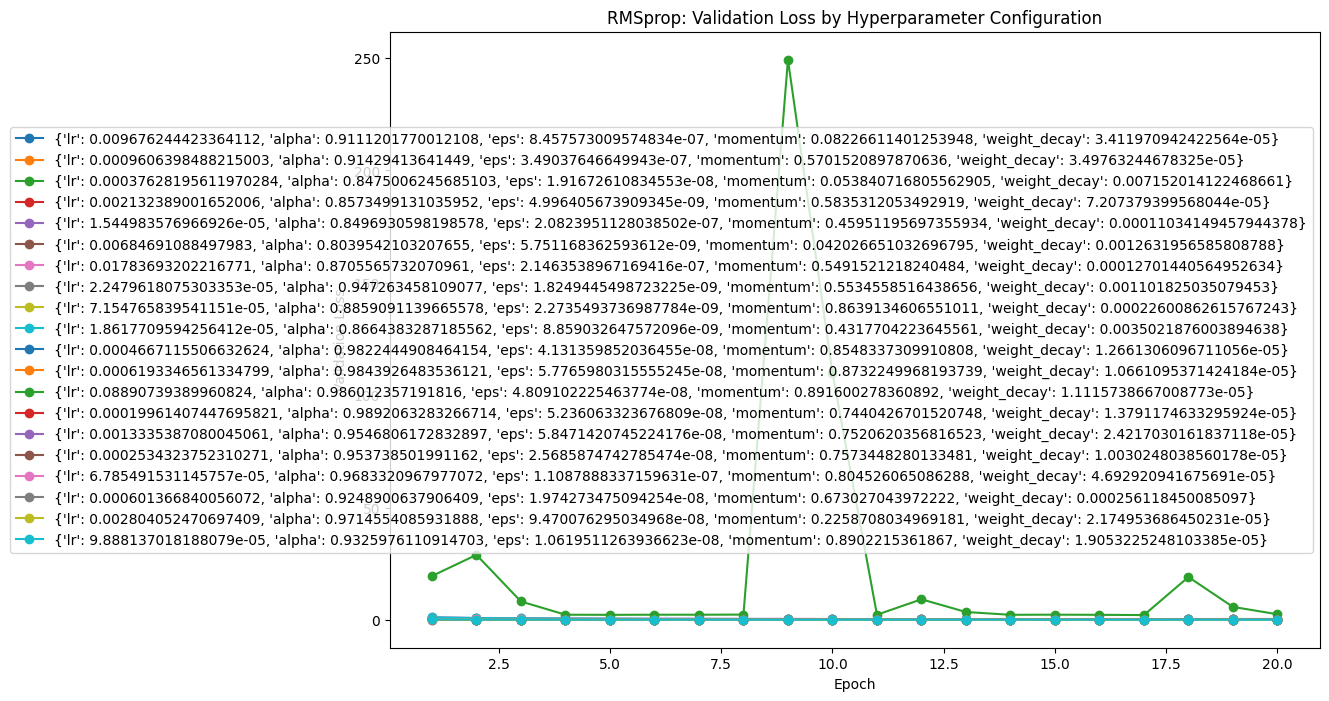

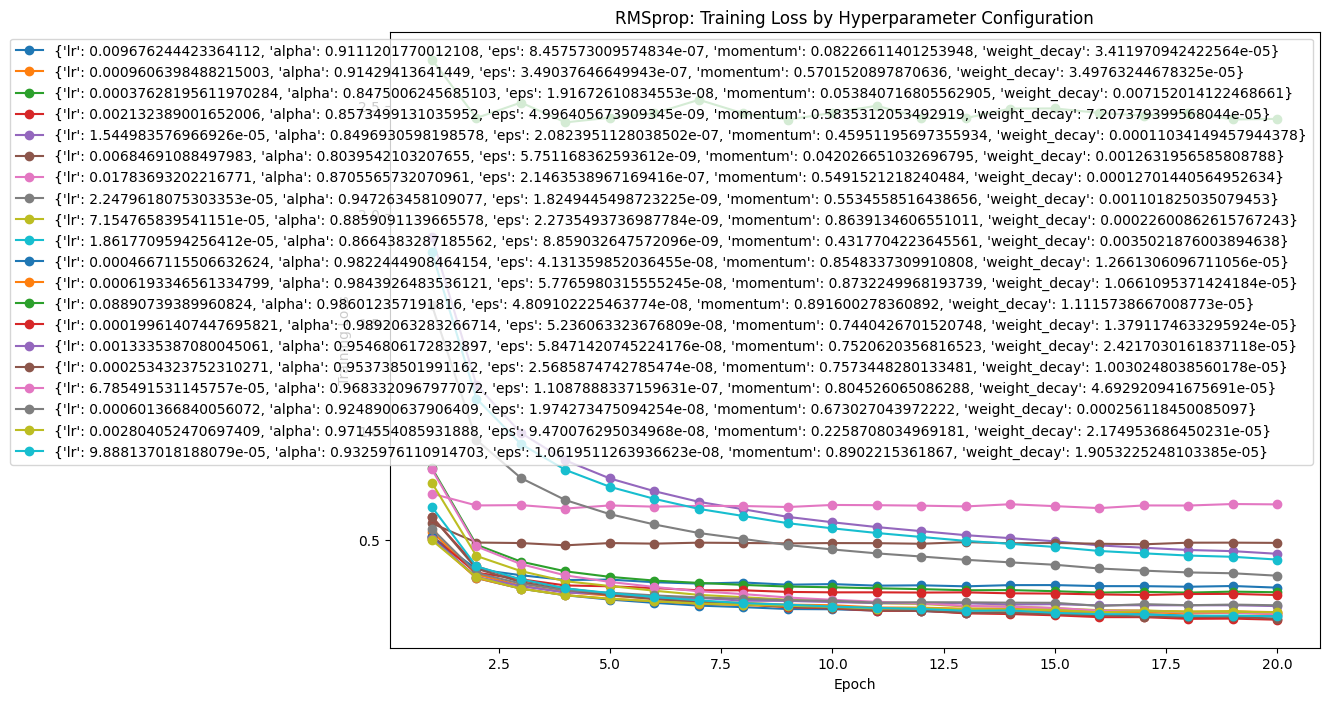

In [18]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # cleaner output

optimizer_name = "RMSprop"
optimizer_class = torch.optim.RMSprop

loss_histories = {}
best_configuration_results = {}

def objective(trial):
    # Optuna suggests hyperparameters instead of your manual list
    config_kwargs = {
        "lr":           trial.suggest_float("lr",           1e-5, 1e-1, log=True),
        "alpha":        trial.suggest_float("alpha",        0.8,  0.99),
        "eps":          trial.suggest_float("eps",          1e-9, 1e-6, log=True),
        "momentum":     trial.suggest_float("momentum",     0.0,  0.9),
        "weight_decay": trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True),
    }

    result = cross_validate_config(
        model_class=FeedForwardNet,
        train_dataset=trainset,
        optimizer_class=optimizer_class,
        optimizer_kwargs=config_kwargs,
        criterion=nn.CrossEntropyLoss(),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        device=device
    )

    loss_histories[str(config_kwargs)] = {
        "train": result[2],
        "val":   result[3],
    }

    return result[0]  # validation accuracy — Optuna maximizes this


# Run the study 
# Maximizing performance metrics instead of loss
study = optuna.create_study(
    direction="maximize"
    sampler=optuna.samplers.TPESampler(seed=MANUAL_SEED)
    )
study.optimize(objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)

# Pull out best results 
best_config_params = study.best_params
best_config_score  = study.best_value

print(f"Best configuration: {best_config_params}")
print(f"Mean Validation Accuracy: {best_config_score:.4f}")

best_configuration_results[optimizer_name] = {
    "params":  best_config_params,
    "metrics": None,  # re-run with best_config_params if you need this
}


plt.figure(figsize=(12, 8))
for label, losses in loss_histories.items():
    plt.plot(range(1, len(losses["val"]) + 1), losses["val"], marker='o', label=label)
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('RMSprop: Validation Loss by Hyperparameter Configuration')
plt.legend()
plt.show()

plt.figure(figsize=(12, 8))
for label, losses in loss_histories.items():
    plt.plot(range(1, len(losses["train"]) + 1), losses["train"], marker='o', label=label)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('RMSprop: Training Loss by Hyperparameter Configuration')
plt.legend()
plt.show()

In [ ]:
import optuna.visualization as vis

# 1. See how the optimization progressed over time
fig_history = vis.plot_optimization_history(study)
fig_history.show()

# 2. See the relationship between hyperparameters and the objective value
# This addresses your concern about seeing which configuration maps to which result
fig_parallel = vis.plot_parallel_coordinate(study)
fig_parallel.show()

# 3. Visualize the importance of each hyperparameter
fig_importance = vis.plot_param_importances(study)
fig_importance.show()

# Branch TODO 3
Modify the code below to suit the selected optimizer (Adam, RMSProp, AdamW).
This code should already retrieve the best configurations tested in TODO 2, but please double check that this is the case.
Adjust other parameters such as the TARGET_ACC as needed; it's currently set to 0.6 for testing purposes.

In [20]:
# Final training with best configurations using full training set

# Refresh seeding and model.
torch.manual_seed(MANUAL_SEED)
final_model = FeedForwardNet().to(device)


final_optimizer = torch.optim.RMSprop(final_model.parameters(), **best_config_params)
loss_function = torch.nn.CrossEntropyLoss()

# Use all of the training dataset + the held-out test set
full_train_loader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)

# 5.4 & 6.2 Req: Track losses and accuracies
train_losses = []
train_accuracies  = []
test_losses = []
test_accuracies = []

# To check convergence speed
convergence_epoch = None

# This ensures time will be synchronized, does not affect GPU performance.
if device.type == "cuda":
    torch.cuda.synchronize()

# Log start time
start_time = time.perf_counter()

for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch(
        final_model, full_train_loader, loss_function, final_optimizer, device, training=True
    )

    # 5.3 Req: Evaluate the final trained model exactly once on the held-out test data
    test_loss, test_acc = run_epoch(
        final_model, testloader, loss_function, optimizer=None, device=device, training=False
    )

    # Store metrics for plotting later
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    
    # Req 5.4: Identify Convergence Epoch
    if test_acc >= TARGET_ACC and convergence_epoch is None:
        convergence_epoch = epoch + 1  # 0-index
        
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

# Stop time
if device.type == "cuda":
    torch.cuda.synchronize()
end_time = time.perf_counter()

# 5.4 Req: Training Time
total_training_time = end_time - start_time

# 5.4 Req: Final Training and Testing Losses
final_train_acc = train_accuracies[-1]
final_test_acc = test_accuracies[-1]

# 5.4 Req: Final Training and Testing Accuracies
final_train_loss = train_losses[-1]
final_test_loss = test_losses[-1]

# If the model never reached the target threshold, default to the max epochs run
if convergence_epoch is None:
    convergence_epoch = EPOCHS

Epoch 1/20
Train Loss: 0.4823 | Train Acc: 0.8498
Test Loss: 0.5236 | Test Acc: 0.8339
Epoch 2/20
Train Loss: 0.3189 | Train Acc: 0.9019
Test Loss: 0.4755 | Test Acc: 0.8512
Epoch 3/20
Train Loss: 0.2702 | Train Acc: 0.9164
Test Loss: 0.4184 | Test Acc: 0.8776
Epoch 4/20
Train Loss: 0.2426 | Train Acc: 0.9244
Test Loss: 0.3821 | Test Acc: 0.8873
Epoch 5/20
Train Loss: 0.2259 | Train Acc: 0.9306
Test Loss: 0.4175 | Test Acc: 0.8761
Epoch 6/20
Train Loss: 0.2109 | Train Acc: 0.9347
Test Loss: 0.4027 | Test Acc: 0.8906
Epoch 7/20
Train Loss: 0.2025 | Train Acc: 0.9374
Test Loss: 0.4166 | Test Acc: 0.8830
Epoch 8/20
Train Loss: 0.1965 | Train Acc: 0.9383
Test Loss: 0.3846 | Test Acc: 0.8880
Epoch 9/20
Train Loss: 0.1848 | Train Acc: 0.9416
Test Loss: 0.3899 | Test Acc: 0.8885
Epoch 10/20
Train Loss: 0.1822 | Train Acc: 0.9436
Test Loss: 0.3927 | Test Acc: 0.8908
Epoch 11/20
Train Loss: 0.1731 | Train Acc: 0.9455
Test Loss: 0.3769 | Test Acc: 0.8980
Epoch 12/20
Train Loss: 0.1691 | Train Ac

# 6. Results 
### 6.1  Summary Table 
Present a table comparing the best configuration of each optimizer across all metrics defined in Section 5.4. Include both default and best configurations for each optimizer. 
 
### 6.2  Required Plots 
- Training and validation loss curves over epochs for the best configuration of each optimizer 
(all three on one plot for direct comparison). 
- Training and validation accuracy curves over epochs. 
- Bar chart comparing final test accuracy across optimizers. 
- Box plot or error-bar plot showing the cross-validation accuracy distribution for each optimizer. 
- Optional: learning-rate sensitivity plot showing validation accuracy vs. learning rate for each optimizer.

### 6.3  Reproducibility 
- State the random seed used. 
- Specify library versions (Python, PyTorch, torchvision). 
- Confirm that results in the report can be reproduced by running the submitted code with no 
modifications.

In [21]:
# 6.1 Requirement Placeholder
# Sample Metric Report (for now)
print("\n" + "="*40)
print("FINAL PRODUCTION RUN METRICS LOG")
print("="*40)
print(f"1. Training Accuracy (Final Epoch): {final_train_acc * 100:.2f}%")
print(f"2. Cross-Validation Accuracy: Mean: {best_config_data[0]:.4f}; Standard Dev: {best_config_data[1]:.4f}")
print(f"3. Test Accuracy: {final_test_acc * 100:.2f}%")
print(f"4. Final Loss:")
print(f"   - Final Training Loss:{final_train_loss:.4f}")
print(f"   - Final Test Loss: {final_test_loss:.4f}")
print(f"5. Convergence Speed: {convergence_epoch} epochs to reach {TARGET_ACC * 100:.0f}% train accuracy")
print(f"6. Total Training Time: {total_training_time:.2f} seconds")
print("="*40)


FINAL PRODUCTION RUN METRICS LOG
1. Training Accuracy (Final Epoch): 95.46%
2. Cross-Validation Accuracy: Mean: 0.9579; Standard Dev: 0.0021
3. Test Accuracy: 89.89%
4. Final Loss:
   - Final Training Loss:0.1428
   - Final Test Loss: 0.3965
5. Convergence Speed: 1 epochs to reach 60% train accuracy
6. Total Training Time: 81.70 seconds


### Final Report TODO:
Based on the requirements mentioned in 6.2, we will need to include all three optimizers in the same notebook. Otherwise, we won't be able to compare them side by side in these plots.

# Branch TODO 4
Use the following graph templates to visualize the results for your optimizer.
Notice that the architecture assumes all three optimizers will be compared in some of the graphs; in this case, double check that the information being populated for the y axis is in the correct order. Currently the placeholder code assumes Adam in index 0.

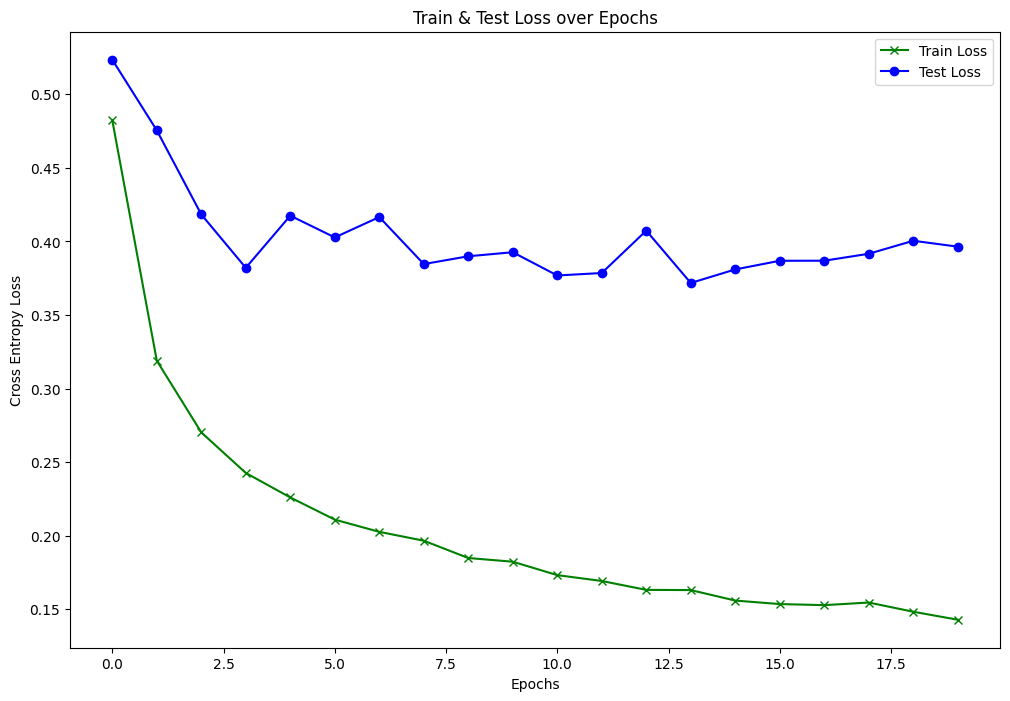

In [22]:
# 6.2: Training and validation loss curves over epochs for the best configuration of each optimizer 
# (all three on one plot for direct comparison).
x = range(EPOCHS)
plt.figure(figsize=(12, 8))
plt.plot(x, train_losses, marker='x', color='g', label='Train Loss')
plt.plot(x, test_losses, marker='o', color='b', label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Cross Entropy Loss')
plt.title('Train & Test Loss over Epochs')
plt.legend()
plt.show()

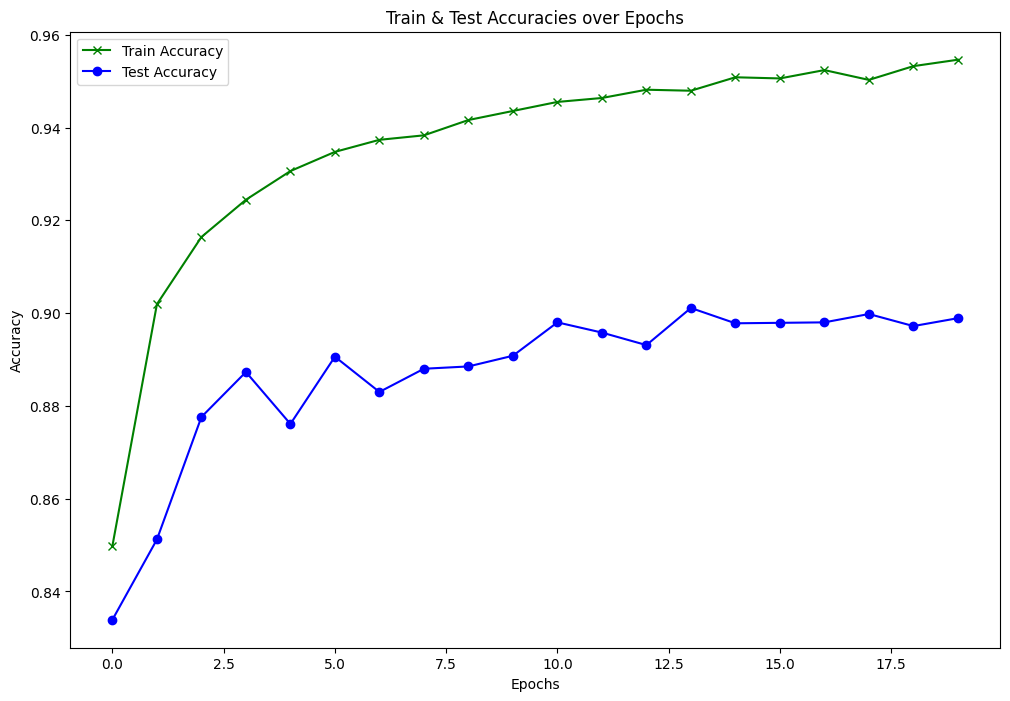

In [23]:
# 6.2: Training and validation accuracy curves over epochs.
x = range(EPOCHS)
plt.figure(figsize=(12, 8))
plt.plot(x, train_accuracies, marker='x', color='g', label='Train Accuracy')
plt.plot(x, test_accuracies, marker='o', color='b', label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Train & Test Accuracies over Epochs')
plt.legend()
plt.show()

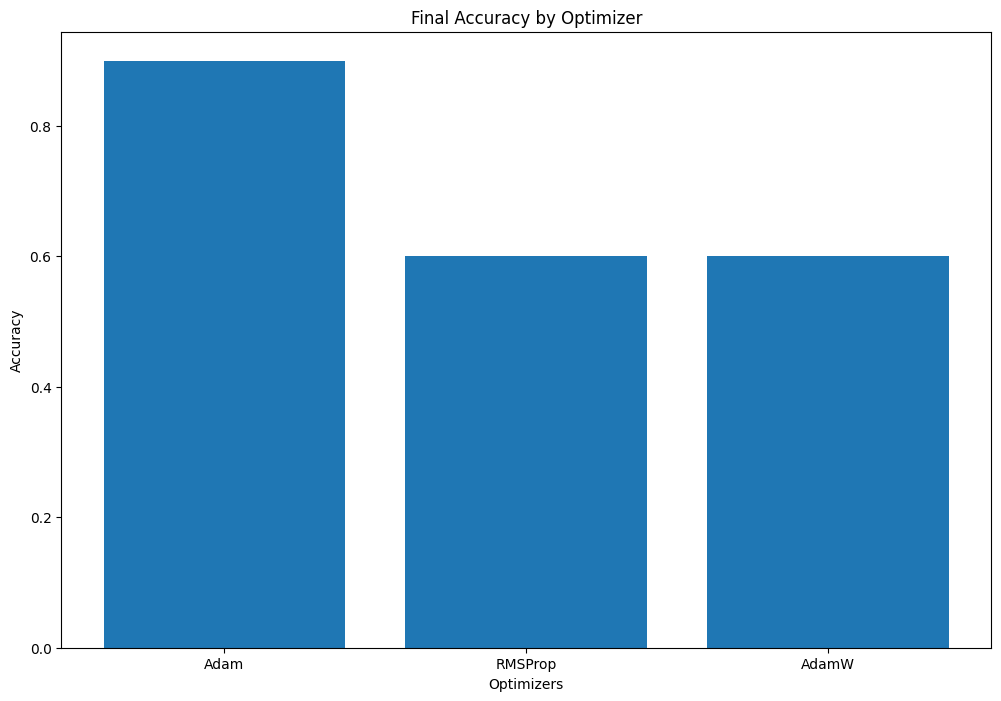

In [24]:
# 6.2: Bar chart comparing final test accuracy across optimizers.
# Placeholder code for now. Will add all optimizers later.
x = ['Adam', 'RMSProp', 'AdamW']
y = [final_test_acc, TARGET_ACC, TARGET_ACC]
plt.figure(figsize=(12, 8))
plt.bar(x, y)
plt.xlabel('Optimizers')
plt.ylabel('Accuracy')
plt.title('Final Accuracy by Optimizer')
plt.show()

In [ ]:
# 6.2: Box plot or error-bar plot showing the cross-validation accuracy distribution for each optimizer.
# Use Error Bar Plot since we only have mean and standard deviations

# Placeholder code for now; will update with all optimizers later.
means = [best_config_data[0], 0.5, 0.8]
stddevs = [best_config_data[1], 0.1, 0.05]

# Define size
plt.figure(figsize=(12, 8))

# Plot the error bar
plt.errorbar(x=x, y=means, yerr=stddevs, fmt='o', color='green', ecolor='red', label= 'CV Accuracy (Mean ± SD)')
plt.title('Cross Validation Accuracy Distribution by Optimizer')
plt.xlabel('Optimizer')
plt.ylabel('Validation Accuracy')


In [ ]:
# 6.2: Optional: learning-rate sensitivity plot showing validation accuracy vs. learning rate for each optimizer. 


In [ ]:
# 6.3 Reproducibility
# Final Report TODO: Will add later.

# 7. Interpretation and Discussion 
### 7.1  Optimizer Analysis 
- Describe the convergence behaviour of each optimizer. Which converged fastest? Which was 
most stable? 
- Discuss  how  each  optimizer  responded  to  learning  rate  changes.  Was  any  optimizer 
particularly sensitive or robust? 
- Compare the generalization gap (train accuracy vs. test accuracy) across optimizers. What 
might explain the differences? 
 
### 7.2  Weight Decay and Regularization 
- Explain,  with  reference  to  your  results,  how  decoupled  weight  decay  in  AdamW  affects 
generalization compared with Adam. 
- If AdamW did not outperform Adam in your experiment, provide a hypothesis for why. 
 
### 7.3  Conclusion and Recommendation 
- State clearly which optimizer performed best on KMNIST and why. 
- Suggest when you would choose each optimizer in a real-world scenario, beyond this specific 
task. 
- Identify at least two limitations of your experimental design and suggest how future work could address them.

# Branch TODO 5
For each of the sections below, conduct analyses based solely on the optimizer chosen first. Ignore the comparisons for now; for instance, just describe the convergence behavior of the selected optimizer (e.g., RMSProp) on its own while including empirical values; these values will be helpful later as we synthesize the findings for the comparison.

In [ ]:
# 7.1 Optimizer Analysis (Single Focus)
# Add information about the convergence behavior of the single optimizer
# Add information about how the optimizer responded to learning rate changes
# Add information about the generalization gap within the single optimizer.


In [ ]:
# 7.2 Weight Decay & Regularization (Not Applicable)


In [ ]:
# 7.3 Conclusion & Recommendation
# Add information about when the optimizer might be chosen for a real-world scenario.
# Identify one limitation in the experimental design with respect to the optimizer
# Suggest how future work may address the limitation.
